In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Tuple, List
from torch.distributions import Categorical
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class LunarLanderEnvironment:
    def __init__(self) -> None:
        self.env = gym.make("LunarLander-v3")
        self.state_dim: int = self.env.observation_space.shape[0]
        self.action_dim: int = self.env.action_space.n

    def reset(self, render: bool) -> torch.Tensor:
        if render:
            self.env = gym.make("LunarLander-v3", render_mode="human")
        else:
            self.env = gym.make("LunarLander-v3")
        state = self.env.reset()
        return self._get_state_tensor(state[0])

    def _get_state_tensor(self, state) -> torch.Tensor:
        return torch.tensor(state, dtype=torch.float32)

    def step(self, action: int) -> Tuple[torch.Tensor, float, bool]:
        next_state, reward, terminated, truncated, _ = self.env.step(action)
        done = terminated or truncated
        return self._get_state_tensor(next_state), reward, done

    def get_action_space_size(self) -> int:
        return self.action_dim

    def get_state_dimension(self) -> int:
        return self.state_dim

    def render(self) -> None:
        self.env.render()

    def close(self) -> None:
        self.env.close()

In [3]:
# Define the Policy Network (Actor)
class PolicyNetwork(nn.Module):
    """ MLP Actor network for PPO """
    def __init__(self, n_observations: int, n_actions: int):
        super(PolicyNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x: torch.Tensor) -> Categorical:
        """
        Forward pass, returns a Categorical distribution.
        """
        if not isinstance(x, torch.Tensor):
             x = torch.tensor(x, dtype=torch.float32, device=device)
        elif x.dtype != torch.float32:
             x = x.to(dtype=torch.float32)
        if x.dim() == 1:
            x = x.unsqueeze(0)
            
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        action_logits = self.layer3(x)
        return Categorical(logits=action_logits)

In [4]:
# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
def update_grpo(
    actor: PolicyNetwork,
    actor_ref: PolicyNetwork, # Reference policy model (frozen)
    actor_optimizer: optim.Optimizer,
    group_states_list: List[torch.Tensor],
    group_actions_list: List[torch.Tensor],
    group_log_probs_old_list: List[torch.Tensor],
    group_advantages_list: List[torch.Tensor], # These are the NORMALIZED advantages
    grpo_epochs: int,
    grpo_clip_epsilon: float,
    grpo_kl_beta: float,       # Coefficient for KL divergence penalty
    entropy_coeff: float       # Coefficient for entropy bonus (optional but often kept)
) -> Tuple[float, float, float]: # Return avg policy objective, avg KL div, avg entropy
    """
    Performs the GRPO update for multiple epochs over the collected group data.

    Parameters:
    - actor (PolicyNetwork): The policy network being trained.
    - actor_ref (PolicyNetwork): The frozen reference policy network for KL calculation.
    - actor_optimizer (optim.Optimizer): The optimizer for the actor network.
    - group_states_list (List[torch.Tensor]): List of state tensors for each rollout.
    - group_actions_list (List[torch.Tensor]): List of action tensors for each rollout.
    - group_log_probs_old_list (List[torch.Tensor]): List of log prob tensors (from actor_ref) for each rollout.
    - group_advantages_list (List[torch.Tensor]): List of NORMALIZED advantage tensors for each rollout.
    - grpo_epochs (int): Number of optimization epochs.
    - grpo_clip_epsilon (float): Clipping parameter epsilon for the surrogate objective.
    - grpo_kl_beta (float): Coefficient for the KL divergence penalty term.
    - entropy_coeff (float): Coefficient for the entropy bonus.

    Returns:
    - Tuple[float, float, float]: Average surrogate objective value (before KL/entropy),
                                   average KL divergence estimate, average entropy over the epochs.
    """
    total_policy_objective = 0.0 # Tracks the clipped surrogate objective part
    total_kl_div = 0.0
    total_entropy = 0.0

    # --- 1. Concatenate Group Data into Batches ---
    # Ensure lists are not empty before concatenation
    if not group_states_list or not group_actions_list or not group_log_probs_old_list or not group_advantages_list:
         print("Warning: Empty lists passed to update_grpo. Skipping update.")
         return 0.0, 0.0, 0.0 # Or handle as appropriate

    try:
        states = torch.cat(group_states_list, dim=0).to(device)
        actions = torch.cat(group_actions_list, dim=0).to(device)
        log_probs_old = torch.cat(group_log_probs_old_list, dim=0).to(device)
        advantages = torch.cat(group_advantages_list, dim=0).to(device)
    except RuntimeError as e:
        print(f"Error during concatenation in update_grpo: {e}")
        # Print shapes for debugging
        print("Shapes:")
        for i in range(len(group_states_list)):
             print(f"  Rollout {i}: States={group_states_list[i].shape}, Actions={group_actions_list[i].shape}, LogProbs={group_log_probs_old_list[i].shape}, Advs={group_advantages_list[i].shape}")
        raise e # Re-raise the error after printing info


    # Detach advantages and old log probs - they are treated as constants during the update
    advantages = advantages.detach()
    log_probs_old = log_probs_old.detach()

    # Ensure reference actor is in eval mode and doesn't track gradients
    actor_ref.eval()

    for epoch in range(grpo_epochs):
        # --- Actor (Policy) Update ---
        # Evaluate current policy
        policy_dist = actor(states)
        log_probs_new = policy_dist.log_prob(actions)
        entropy = policy_dist.entropy().mean() # Entropy for exploration bonus

        # Calculate ratio r_t(theta) = pi_theta(a|s) / pi_theta_old(a|s)
        # log_probs_old comes from the policy *at the time of sampling*, which acts as pi_theta_old
        ratio = torch.exp(log_probs_new - log_probs_old)

        # Calculate surrogate objectives
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1.0 - grpo_clip_epsilon, 1.0 + grpo_clip_epsilon) * advantages

        # Clipped Surrogate Objective part of the loss
        clipped_surrogate_objective = torch.min(surr1, surr2).mean()

        # --- Calculate KL Divergence Penalty ---
        kl_div_estimate_mean = 0.0
        with torch.no_grad(): # Ensure no gradients computed for reference policy
             policy_dist_ref = actor_ref(states)
             log_probs_ref = policy_dist_ref.log_prob(actions)

        # Calculate KL divergence using the unbiased estimator
        # D_KL = (pi_ref / pi_theta) - log(pi_ref / pi_theta) - 1
        #      = exp(log_probs_ref - log_probs_new) - (log_probs_ref - log_probs_new) - 1
        # Detach log_probs_new here to prevent grads flowing through KL term backprop path incorrectly?
        # The gradient should only come from the direct dependence of the main objective on pi_theta.
        # Let's compute KL term separately and add its gradient scaled by beta.
        # Re-evaluate log_probs_new *without* detaching for the main objective gradient.
        log_ratio_ref_curr = log_probs_ref - log_probs_new.detach() # Use detached version for KL calculation
        kl_div_estimate = torch.exp(log_ratio_ref_curr) - log_ratio_ref_curr - 1
        kl_div_estimate_mean = kl_div_estimate.mean()

        # Ensure KL estimate is non-negative (it should be theoretically)
        kl_div_estimate_mean = torch.relu(kl_div_estimate_mean)


        # --- Combine Loss Terms ---
        # We want to MAXIMIZE the surrogate objective and MINIMIZE KL and entropy penalty
        # Optimizer minimizes loss, so: Loss = -Surrogate + KL_Penalty + Entropy_Penalty
        # Loss = -clipped_surrogate_objective + grpo_kl_beta * kl_div_estimate_mean - entropy_coeff * entropy
        # Note: The paper's formula (Eq 3) puts beta outside the KL term. Let's follow that.
        # Maximize: min(...) - beta * D_KL(...) => Minimize: -min(...) + beta * D_KL(...)
        # Adding entropy bonus: Minimize: -min(...) + beta * D_KL(...) - entropy_coeff * entropy
        
        policy_loss = -clipped_surrogate_objective + grpo_kl_beta * kl_div_estimate_mean - entropy_coeff * entropy


        # Optimize the actor
        actor_optimizer.zero_grad()
        policy_loss.backward()
        # Optional: Gradient Clipping
        # torch.nn.utils.clip_grad_norm_(actor.parameters(), max_norm=0.5)
        actor_optimizer.step()

        # Accumulate metrics for logging (use .item() to detach)
        total_policy_objective += clipped_surrogate_objective.item() # Store the positive objective value
        total_kl_div += kl_div_estimate_mean.item()
        total_entropy += entropy.item()

    # Calculate average metrics over the epochs
    avg_policy_objective = total_policy_objective / grpo_epochs
    avg_kl_div = total_kl_div / grpo_epochs
    avg_entropy = total_entropy / grpo_epochs

    return avg_policy_objective, avg_kl_div, avg_entropy

In [6]:
# --- GRPO Hyperparameters ---
GAMMA_GRPO = 0.994              # Discount factor
GRPO_KL_BETA = 0.005            # KL penalty factor
ACTOR_LR_GRPO = 3e-4           # Learning rate for the actor
GRPO_EPOCHS = 10               # Number of optimization epochs per iteration
GRPO_CLIP_EPSILON = 0.2        # GRPO clipping epsilon (used inside update_grpo)
ENTROPY_COEFF_GRPO = 0.005      # Coefficient for entropy bonus (used inside update_grpo)
NUM_ITERATIONS_GRPO = 400      # Number of GRPO iterations (policy updates)
GROUP_SIZE = 32                # Number of rollouts (episodes) per group (G)
MAX_STEPS_PER_EPISODE_GRPO = 1000 # Max steps per episode
EPSILON_STD = 1e-8             # Small value to prevent division by zero
INTERV_PRINT = 10              # Print losses every INTERV_PRINT steps
INTERV_RENDER = -1             # Render environment every INTERV_RENDER steps, if INTERV_RENDER = -1, it doesn't render

In [7]:
# --- Initialization ---
env_grpo: LunarLanderEnvironment = LunarLanderEnvironment()
n_actions_grpo: int = env_grpo.get_action_space_size()
n_observations_grpo: int = env_grpo.get_state_dimension()
actor_grpo: PolicyNetwork = PolicyNetwork(n_observations_grpo, n_actions_grpo).to(device)

# Initialize Optimizer for Actor
actor_optimizer_grpo: optim.Adam = optim.Adam(actor_grpo.parameters(), lr=ACTOR_LR_GRPO)

# Lists for plotting/logging
grpo_iteration_rewards = []
grpo_iteration_avg_ep_lens = []
grpo_iteration_policy_losses = []
grpo_iteration_entropies = []
grpo_iteration_kl_divs = []

print("Starting GRPO Training on LunarLander...")

# --- GRPO Training Loop ---
for iteration in range(NUM_ITERATIONS_GRPO):
    # --- 1. Collect Group of Trajectories (Rollout Phase) ---
    group_states_list: List[torch.Tensor] = []
    group_actions_list: List[torch.Tensor] = []
    group_log_probs_old_list: List[torch.Tensor] = [] # Log probs at time of sampling
    group_rewards_list: List[List[float]] = []      # Store raw rewards per rollout

    episode_rewards_in_iter = []
    episode_lengths_in_iter = []

    actor_grpo.eval() # Set actor to evaluation mode for rollout
    for rollout_idx in range(GROUP_SIZE):
        rollout_states: List[torch.Tensor] = []
        rollout_actions: List[torch.Tensor] = []
        rollout_log_probs: List[torch.Tensor] = []
        rollout_rewards: List[float] = []

        if INTERV_RENDER != -1:
            if rollout_idx==0 and iteration%INTERV_RENDER==0:
                state = env_grpo.reset(render=True)
            else:
                state = env_grpo.reset(render=False)
        else:
            state = env_grpo.reset(render=False)
        
        
        episode_reward = 0.0
        episode_steps = 0
        done = False

        for t in range(MAX_STEPS_PER_EPISODE_GRPO):
            # Sample action and get log_prob
            with torch.no_grad():
                 if not isinstance(state, torch.Tensor):
                      state_tensor = torch.tensor(state, dtype=torch.float32, device=device)
                 else:
                      state_tensor = state.to(device)

                 policy_dist = actor_grpo(state_tensor)
                 action_tensor = policy_dist.sample()
                 log_prob = policy_dist.log_prob(action_tensor)


            # Interact with environment
            action_item = action_tensor.item()
            next_state, reward, done = env_grpo.step(action_item)

            # Store data for this step in the current rollout
            rollout_states.append(state_tensor)
            rollout_actions.append(action_tensor)
            rollout_log_probs.append(log_prob)
            rollout_rewards.append(reward)

            state = next_state
            episode_reward += reward
            episode_steps += 1

            if done:
                break

        # Store the completed rollout data as tensors
        if rollout_states:
             group_states_list.append(torch.stack(rollout_states))
             action_dim = rollout_actions[0].dim() if rollout_actions else 0
             log_prob_dim = rollout_log_probs[0].dim() if rollout_log_probs else 0
             # Squeeze added dimensions if they exist from stacking scalar tensors
             group_actions_list.append(torch.stack(rollout_actions).squeeze() if action_dim > 0 else torch.tensor([a.item() for a in rollout_actions], device=device))
             group_log_probs_old_list.append(torch.stack(rollout_log_probs).squeeze() if log_prob_dim > 0 else torch.tensor([lp.item() for lp in rollout_log_probs], device=device))
             group_rewards_list.append(rollout_rewards)
        else:
             # Keep warning for empty rollouts as it might indicate issues
             # print(f"Warning: Rollout {rollout_idx+1} in iteration {iteration+1} was empty.") # Keep this print commented unless debugging
             group_states_list.append(torch.empty((0, n_observations_grpo), device=device))
             group_actions_list.append(torch.empty((0,), dtype=torch.long, device=device))
             group_log_probs_old_list.append(torch.empty((0,), device=device))
             group_rewards_list.append([])

        episode_rewards_in_iter.append(episode_reward)
        episode_lengths_in_iter.append(episode_steps)

    actor_grpo.train() # Set actor back to training mode for update

    # --- 2. Calculate Group Relative Advantages (Discounted Returns Method) ---
    group_advantages_list: List[torch.Tensor] = [] # Will store FINAL normalized advantages
    all_raw_advantages_in_group: List[float] = [] # Temp storage for mean/std calc (advantages are now discounted returns)
    temp_raw_advantages_tensors: List[torch.Tensor] = [] # Store raw tensors before normalization

    # --- First Pass: Calculate RAW discounted returns-to-go and collect them ---
    for i, rollout_rewards in enumerate(group_rewards_list):
        rollout_len = len(rollout_rewards)
        # Renamed to reflect it's discounted returns, but keeping variable name for consistency
        rollout_raw_advantages = torch.zeros(rollout_len, dtype=torch.float32, device=device)

        if rollout_len > 0:
            # Calculate raw discounted returns (G_t = r_t + gamma*G_{t+1})
            discounted_return = 0.0
            for t in reversed(range(rollout_len)):
                discounted_return = rollout_rewards[t] + GAMMA_GRPO * discounted_return # Apply discount factor
                rollout_raw_advantages[t] = discounted_return

            # Store raw advantages (discounted returns) for later normalization
            temp_raw_advantages_tensors.append(rollout_raw_advantages)
            all_raw_advantages_in_group.extend(rollout_raw_advantages.cpu().numpy()) # Collect as list of floats
        else:
            temp_raw_advantages_tensors.append(torch.empty((0,), device=device)) # Placeholder for empty

    # --- Calculate Mean/Std of ALL RAW discounted returns ---
    if len(all_raw_advantages_in_group) > 1:
        group_mean_advantage = np.mean(all_raw_advantages_in_group)
        group_std_advantage = np.std(all_raw_advantages_in_group)
    elif len(all_raw_advantages_in_group) == 1:
         group_mean_advantage = all_raw_advantages_in_group[0]
         group_std_advantage = 0.0
    else:
        group_mean_advantage = 0.0
        group_std_advantage = 0.0
        # Keep this warning as it's important if no advantages are calculated
        if iteration == 0: # Only print once if it persists
             print("Warning: No advantages calculated in group (all rollouts empty?).")


    # --- Second Pass: Normalize raw discounted returns ---
    for i, raw_advantages_tensor in enumerate(temp_raw_advantages_tensors):
        if raw_advantages_tensor.nelement() > 0:
             # Normalize using the group's mean/std of discounted returns
             normalized_advantages = (raw_advantages_tensor - group_mean_advantage) / (group_std_advantage + EPSILON_STD)
        else:
             normalized_advantages = raw_advantages_tensor

        group_advantages_list.append(normalized_advantages)

    # --- Create Reference Actor (Copy current actor state) ---
    actor_ref = PolicyNetwork(n_observations_grpo, n_actions_grpo).to(device)
    actor_ref.load_state_dict(actor_grpo.state_dict())
    actor_ref.eval() # Set to evaluation mode
    
    # --- 3. Perform GRPO Update ---
    avg_policy_obj, avg_kl, avg_entropy = update_grpo(
        actor=actor_grpo,                 # The actor being trained
        actor_ref=actor_ref,              # The frozen reference actor
        actor_optimizer=actor_optimizer_grpo,
        group_states_list=group_states_list,
        group_actions_list=group_actions_list,
        group_log_probs_old_list=group_log_probs_old_list, # Log probs from sampling time
        group_advantages_list=group_advantages_list,      # Final NORMALIZED advantages
        grpo_epochs=GRPO_EPOCHS,
        grpo_clip_epsilon=GRPO_CLIP_EPSILON,
        grpo_kl_beta=GRPO_KL_BETA,
        entropy_coeff=ENTROPY_COEFF_GRPO
    )
    
    # Store losses for logging/plotting
    # Note: avg_policy_obj is the surrogate value, not the final combined loss
    grpo_iteration_policy_losses.append(avg_policy_obj) # Or store the combined loss if preferred
    grpo_iteration_entropies.append(avg_entropy)
    grpo_iteration_kl_divs.append(avg_kl)
    # --- Logging ---
    avg_reward_iter = np.mean(episode_rewards_in_iter) if episode_rewards_in_iter else np.nan
    avg_len_iter = np.mean(episode_lengths_in_iter) if episode_lengths_in_iter else np.nan

    grpo_iteration_rewards.append(avg_reward_iter)
    grpo_iteration_avg_ep_lens.append(avg_len_iter)

    # Print summary log every N iterations (e.g., 10)
    if (iteration + 1) % INTERV_PRINT == 0 or iteration == NUM_ITERATIONS_GRPO - 1:
        print(f"Iter {iteration+1}/{NUM_ITERATIONS_GRPO} | Avg Reward (Group): {avg_reward_iter:.2f} | Avg Len (Group): {avg_len_iter:.1f} | P_loss: {avg_policy_obj:.4f} | Entropy: {avg_entropy:.4f}")


print("\nGRPO Training Loop Finished (LunarLander).")
env_grpo.close()

Starting GRPO Training on LunarLander...
Iter 10/400 | Avg Reward (Group): -108.55 | Avg Len (Group): 88.0 | P_loss: 0.0016 | Entropy: 1.3349
Iter 20/400 | Avg Reward (Group): -48.62 | Avg Len (Group): 142.5 | P_loss: 0.0009 | Entropy: 1.2045
Iter 30/400 | Avg Reward (Group): -99.20 | Avg Len (Group): 323.2 | P_loss: 0.0012 | Entropy: 1.1328
Iter 40/400 | Avg Reward (Group): -32.32 | Avg Len (Group): 218.7 | P_loss: 0.0010 | Entropy: 1.1606
Iter 50/400 | Avg Reward (Group): 14.60 | Avg Len (Group): 525.2 | P_loss: 0.0004 | Entropy: 1.2472
Iter 60/400 | Avg Reward (Group): 57.26 | Avg Len (Group): 630.8 | P_loss: 0.0005 | Entropy: 1.2111
Iter 70/400 | Avg Reward (Group): 80.88 | Avg Len (Group): 823.4 | P_loss: 0.0005 | Entropy: 1.1408
Iter 80/400 | Avg Reward (Group): 110.26 | Avg Len (Group): 950.5 | P_loss: 0.0002 | Entropy: 1.1570
Iter 90/400 | Avg Reward (Group): 85.47 | Avg Len (Group): 869.4 | P_loss: 0.0005 | Entropy: 1.1522
Iter 100/400 | Avg Reward (Group): 104.75 | Avg Len (G

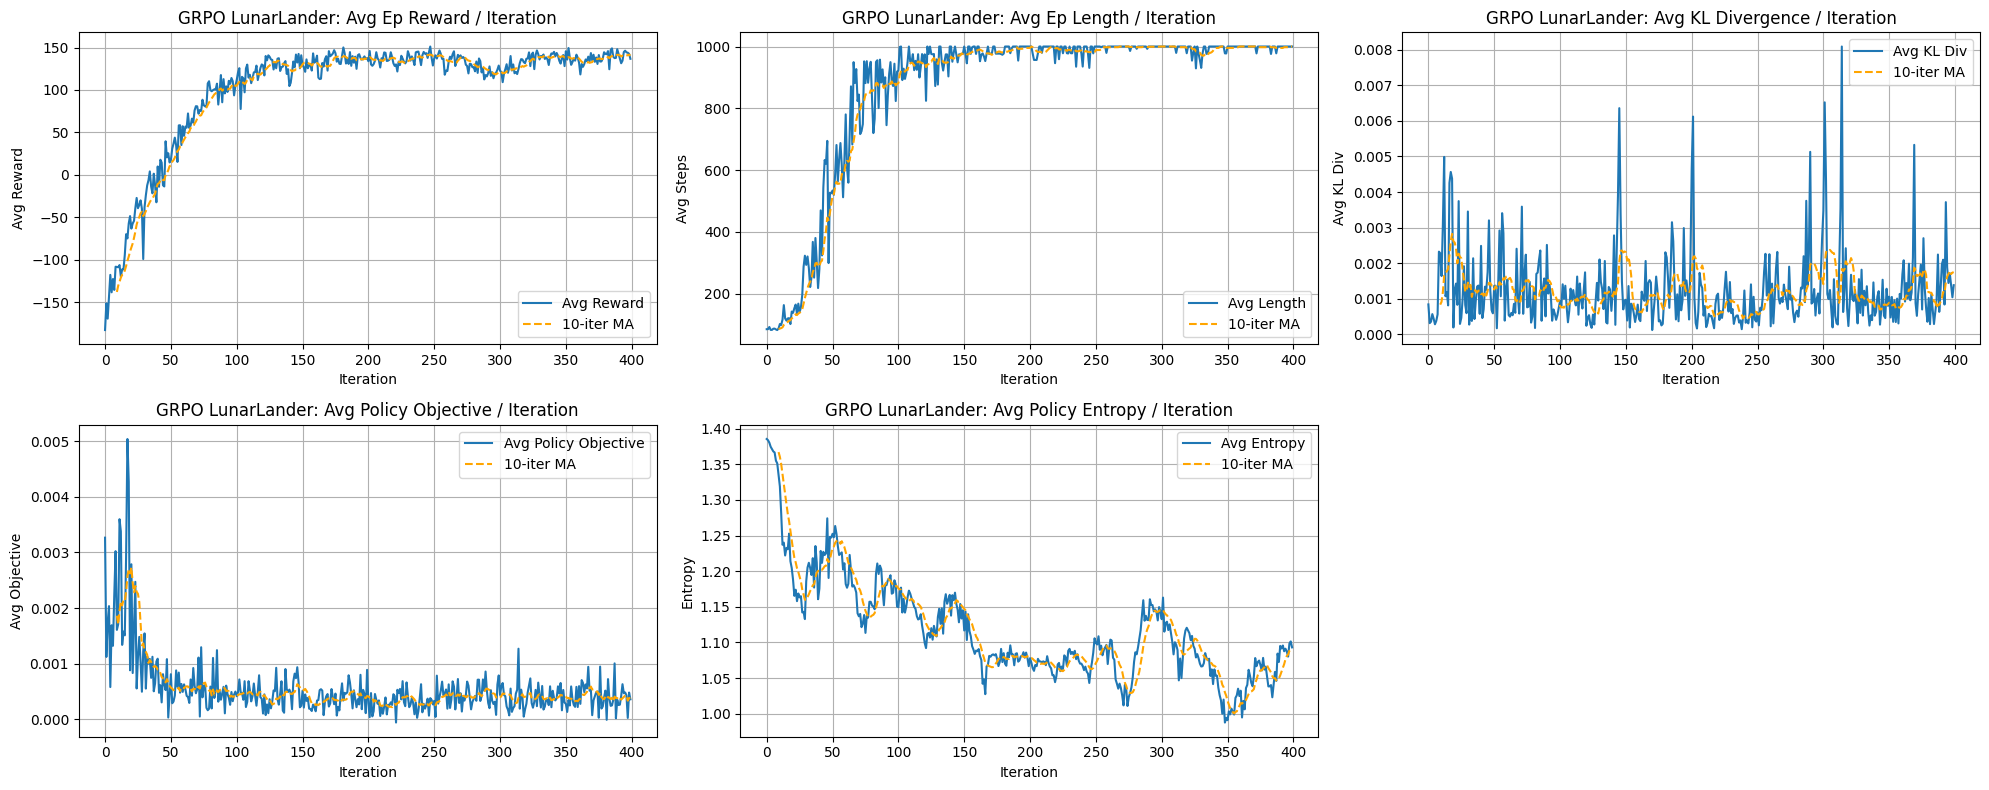

In [8]:
# Assume the following lists have been populated during the GRPO training loop:
# grpo_iteration_rewards = [...]
# grpo_iteration_avg_ep_lens = [...]
# grpo_iteration_policy_losses = [...] # Should contain avg_policy_obj values
# grpo_iteration_kl_divs = [...]      # Should contain avg_kl values
# grpo_iteration_entropies = [...]     # Should contain avg_entropy values

# --- Plotting results for GRPO ---
plt.figure(figsize=(20, 8)) # Use a 2x3 layout similar to PPO, leaving one spare

# --- 1. Average Rewards per Iteration ---
plt.subplot(2, 3, 1)
# Filter out potential NaN values if environment interaction failed
valid_rewards_grpo = [r for r in grpo_iteration_rewards if r is not None and not np.isnan(r)]
valid_indices_grpo = [i for i, r in enumerate(grpo_iteration_rewards) if r is not None and not np.isnan(r)]
if valid_indices_grpo: # Check if there's anything to plot
    plt.plot(valid_indices_grpo, valid_rewards_grpo, label='Avg Reward')
    plt.title('GRPO LunarLander: Avg Ep Reward / Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Avg Reward')
    plt.grid(True)
    # Add moving average if enough data points
    if len(valid_rewards_grpo) >= 10:
        rewards_ma_grpo = np.convolve(valid_rewards_grpo, np.ones(10)/10, mode='valid')
        # Adjust indices for moving average plot
        ma_indices_rewards = valid_indices_grpo[len(valid_rewards_grpo) - len(rewards_ma_grpo):]
        plt.plot(ma_indices_rewards, rewards_ma_grpo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
else:
    plt.title('GRPO LunarLander: Avg Ep Reward / Iteration (No Data)')

# --- 2. Average Episode Length per Iteration ---
plt.subplot(2, 3, 2)
# Filter out potential NaN values
valid_lens_grpo = [l for l in grpo_iteration_avg_ep_lens if l is not None and not np.isnan(l)]
valid_indices_len_grpo = [i for i, l in enumerate(grpo_iteration_avg_ep_lens) if l is not None and not np.isnan(l)]
if valid_indices_len_grpo: # Check if there's anything to plot
    plt.plot(valid_indices_len_grpo, valid_lens_grpo, label='Avg Length')
    plt.title('GRPO LunarLander: Avg Ep Length / Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Avg Steps')
    plt.grid(True)
    # Add moving average
    if len(valid_lens_grpo) >= 10:
        lens_ma_grpo = np.convolve(valid_lens_grpo, np.ones(10)/10, mode='valid')
        ma_indices_lens = valid_indices_len_grpo[len(valid_lens_grpo) - len(lens_ma_grpo):]
        plt.plot(ma_indices_lens, lens_ma_grpo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
else:
    plt.title('GRPO LunarLander: Avg Ep Length / Iteration (No Data)')


# --- 3. Average KL Divergence per Iteration ---
plt.subplot(2, 3, 3)
if grpo_iteration_kl_divs: # Check if list has data
    plt.plot(grpo_iteration_kl_divs, label='Avg KL Div')
    plt.title('GRPO LunarLander: Avg KL Divergence / Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Avg KL Div')
    plt.grid(True)
    # Add moving average
    if len(grpo_iteration_kl_divs) >= 10:
        kl_ma_grpo = np.convolve(grpo_iteration_kl_divs, np.ones(10)/10, mode='valid')
        # Simple indexing for MA assumes iterations start from 0 and are continuous
        plt.plot(np.arange(len(kl_ma_grpo)) + (10 - 1), kl_ma_grpo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
else:
     plt.title('GRPO LunarLander: Avg KL Divergence / Iteration (No Data)')


# --- 4. Actor Policy Objective per Iteration ---
plt.subplot(2, 3, 4)
# NOTE: Plotting the OBJECTIVE value directly (we want to maximize this)
#       This corresponds to the `avg_policy_obj` from update_grpo
if grpo_iteration_policy_losses: # Check if list has data
    plt.plot(grpo_iteration_policy_losses, label='Avg Policy Objective')
    plt.title('GRPO LunarLander: Avg Policy Objective / Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Avg Objective')
    plt.grid(True)
    # Add moving average
    if len(grpo_iteration_policy_losses) >= 10:
        pobj_ma_grpo = np.convolve(grpo_iteration_policy_losses, np.ones(10)/10, mode='valid')
        plt.plot(np.arange(len(pobj_ma_grpo)) + (10 - 1), pobj_ma_grpo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
else:
     plt.title('GRPO LunarLander: Avg Policy Objective / Iteration (No Data)')


# --- 5. Entropy per Iteration ---
plt.subplot(2, 3, 5)
if grpo_iteration_entropies: # Check if list has data
    plt.plot(grpo_iteration_entropies, label='Avg Entropy')
    plt.title('GRPO LunarLander: Avg Policy Entropy / Iteration')
    plt.xlabel('Iteration')
    plt.ylabel('Entropy')
    plt.grid(True)
    # Add moving average
    if len(grpo_iteration_entropies) >= 10:
        entropy_ma_grpo = np.convolve(grpo_iteration_entropies, np.ones(10)/10, mode='valid')
        plt.plot(np.arange(len(entropy_ma_grpo)) + (10 - 1), entropy_ma_grpo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
else:
     plt.title('GRPO LunarLander: Avg Policy Entropy / Iteration (No Data)')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()